In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-10-31 16:24:19.111501: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-31 16:24:19.111882: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-31 16:24:19.177467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-31 16:24:22.257738: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [3]:
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

In [4]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [5]:
mdata = mu.read("merged_EAE.h5mu")

In [6]:
mdata['airr'].obs['GSE'] = mdata.obs['GSE']

# embed TCR AA into vector

In [7]:
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']
tcr_num_features = []

In [8]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}


In [9]:
def encode_tcr_sequence(seq, max_length, atchley_factors):
    """
    Encode a TCR amino acid sequence into a vector using Atchley factors.
    
    Parameters:
    - seq: amino acid sequence string
    - max_length: maximum sequence length for padding
    - atchley_factors: dictionary mapping amino acids to their Atchley factors
    
    Returns:
    - numpy array of shape ((max_length+1)*5,)
    """
    vector = []
    
    # Handle None or NaN values
    if pd.isna(seq) or seq is None:
        return np.zeros((max_length + 1) * 5)
    
    # Convert sequence to uppercase
    seq = str(seq).upper()
    
    # Encode each amino acid
    for aa in seq:
        if aa in atchley_factors:
            vector.extend(atchley_factors[aa])
        else:
            # Unknown amino acid, use zeros
            vector.extend([0, 0, 0, 0, 0])
    
    # Pad with zeros to reach (max_length+1)*5
    current_length = len(vector)
    target_length = (max_length + 1) * 5
    vector.extend([0] * (target_length - current_length))
    
    return np.array(vector)

def vectorize_tcr_column(mdata, column_name, atchley_factors):
    """
    Vectorize a TCR amino acid column in mdata.obs using Atchley factors.
    
    Parameters:
    - mdata: MuData object
    - column_name: name of the column containing TCR sequences
    - atchley_factors: dictionary mapping amino acids to their Atchley factors
    
    Returns:
    - numpy array of shape (n_obs, (L+1)*5) where L is max sequence length
    """
    # Get the column data
    sequences = mdata.obs[column_name]
    
    # Find maximum length L
    max_length = mdata.obs[column_name].str.len().max()

    # Encode all sequences
    encoded_vectors = []
    for seq in sequences:
        vec = encode_tcr_sequence(seq, max_length, atchley_factors)
        encoded_vectors.append(vec)
    
    return np.array(encoded_vectors)


In [10]:
def compute_aa_composition(seq):
    """
    Compute the percentage composition of each of the 20 amino acids.
    
    Parameters:
    - seq: amino acid sequence string
    
    Returns:
    - numpy array of shape (20,) with percentages for each AA
    """
    # Standard 20 amino acids in alphabetical order
    standard_aas = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 
                    'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    
    # Handle None or NaN values
    if pd.isna(seq) or seq is None:
        return np.zeros(20)
    
    # Convert to uppercase and count
    seq = str(seq).upper()
    seq_len = len(seq)
    
    if seq_len == 0:
        return np.zeros(20)
    
    # Count each amino acid
    aa_counts = np.zeros(20)
    for i, aa in enumerate(standard_aas):
        aa_counts[i] = seq.count(aa)
    
    # Convert to percentages
    aa_percentages = aa_counts / seq_len
    
    return aa_percentages

def compute_aa_composition_matrix(mdata, column_name):
    """
    Compute AA composition for all sequences in a column.
    
    Parameters:
    - mdata: MuData object
    - column_name: name of the column containing TCR sequences
    
    Returns:
    - numpy array of shape (n_obs, 20) with AA composition percentages
    """
    sequences = mdata.obs[column_name]
    composition_matrix = np.array([compute_aa_composition(seq) for seq in sequences])
    return composition_matrix

def compute_sequence_lengths(mdata, column_name):
    """
    Compute the length of each sequence in a column.
    
    Parameters:
    - mdata: MuData object
    - column_name: name of the column containing TCR sequences
    
    Returns:
    - numpy array of sequence lengths
    """
    sequences = mdata.obs[column_name]
    lengths = np.array([len(str(seq)) if pd.notna(seq) and seq is not None else 0 for seq in sequences])
    return lengths


In [11]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Atchley factor encoding
    encoded = vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2. AA composition (percentage of each of 20 AAs)
    aa_comp = compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}")
    
    # 3. Sequence length
    lengths = compute_sequence_lengths(mdata, aa_col)
    len_key = f'{aa_col}_length'
    mdata.obs[len_key] = lengths
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']\n")


Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (105261, 140)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (105261, 20)
Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']

Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (105261, 185)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (105261, 20)
Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']



In [12]:
def onehot_encode_categorical(mdata, column_name):
    """
    One-hot encode a categorical column with an additional dimension for unknown/missing values.
    
    Parameters:
    - mdata: MuData object
    - column_name: name of the column to encode
    
    Returns:
    - numpy array of shape (n_obs, n_categories + 1) where +1 is for unknown/missing
    """
    # Get the column data
    data = mdata.obs[column_name]
    
    # Get unique non-null categories
    categories = sorted([x for x in data.unique() if pd.notna(x)])
    n_categories = len(categories)
    
    print(f"{column_name}: {n_categories} unique categories + 1 unknown = {n_categories + 1} dimensions")
    
    # Create category to index mapping
    cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}
    
    # Initialize one-hot matrix (last column is for unknown)
    onehot_matrix = np.zeros((len(data), n_categories + 1))
    
    # Fill in one-hot encoding
    for i, value in enumerate(data):
        if pd.isna(value) or value not in cat_to_idx:
            # Unknown/missing value goes in the last column
            onehot_matrix[i, -1] = 1
        else:
            # Known category
            onehot_matrix[i, cat_to_idx[value]] = 1
    
    return onehot_matrix

# One-hot encode all categorical TCR features and concatenate
cat_encoded_list = []
for cat_col in tcr_cat_features:
    encoded = onehot_encode_categorical(mdata, cat_col)
    # cat_encoded_list.append(encoded)
    mdata.obsm[cat_col] = encoded

# Concatenate all one-hot encoded vectors
# tcr_cat_onehot = np.concatenate(cat_encoded_list, axis=1)

mdata_ori = mdata.copy()


VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 24 unique categories + 1 unknown = 25 dimensions
VJ_1_j_call: 43 unique categories + 1 unknown = 44 dimensions
VJ_1_v_call: 98 unique categories + 1 unknown = 99 dimensions


# Subsets

#### only cloned TCRs

In [13]:
mdata_cloned = mdata[mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > 1].copy()

#### select only one cell from each clonotype

In [14]:
# Randomly keep one cell per clone_id within each GSE subset
airr = mdata_cloned['airr']
print(f"Original number of cells: {airr.n_obs}")

# Store indices to keep
indices_to_keep = []

# Group by GSE
for gse in airr.obs['GSE'].unique():
    # Get cells for this GSE
    gse_mask = airr.obs['GSE'] == gse
    gse_obs = airr.obs[gse_mask]
    
    print(f"\nGSE: {gse} - Original cells: {len(gse_obs)}")
    
    # For each clone_id in this GSE, randomly select one cell
    for clone_id in gse_obs['clone_id'].unique():
        clone_cells = gse_obs[gse_obs['clone_id'] == clone_id]
        # Randomly sample one cell from this clone
        selected_idx = clone_cells.sample(n=1, random_state=42).index[0]
        indices_to_keep.append(selected_idx)
    
    print(f"GSE: {gse} - After sampling: {len(gse_obs['clone_id'].unique())} cells (one per clone)")

# Create subset with selected cells
mdata_cloned_oneCell = mdata[indices_to_keep].copy()

print(f"\n{'='*60}")
print(f"Total cells after sampling: {mdata['airr'].n_obs}")
print(f"Reduction: {airr.n_obs} -> {mdata['airr'].n_obs} cells")

Original number of cells: 40327

GSE: LEE - Original cells: 6310
GSE: LEE - After sampling: 1689 cells (one per clone)

GSE: GSE156718 - Original cells: 3182
GSE: GSE156718 - After sampling: 1111 cells (one per clone)

GSE: GSE293883 - Original cells: 2483
GSE: GSE293883 - After sampling: 652 cells (one per clone)

GSE: GSE188320 - Original cells: 28352
GSE: GSE188320 - After sampling: 4549 cells (one per clone)

Total cells after sampling: 105261
Reduction: 40327 -> 105261 cells


## select subset

In [36]:
mdata = mdata_cloned

# clusters

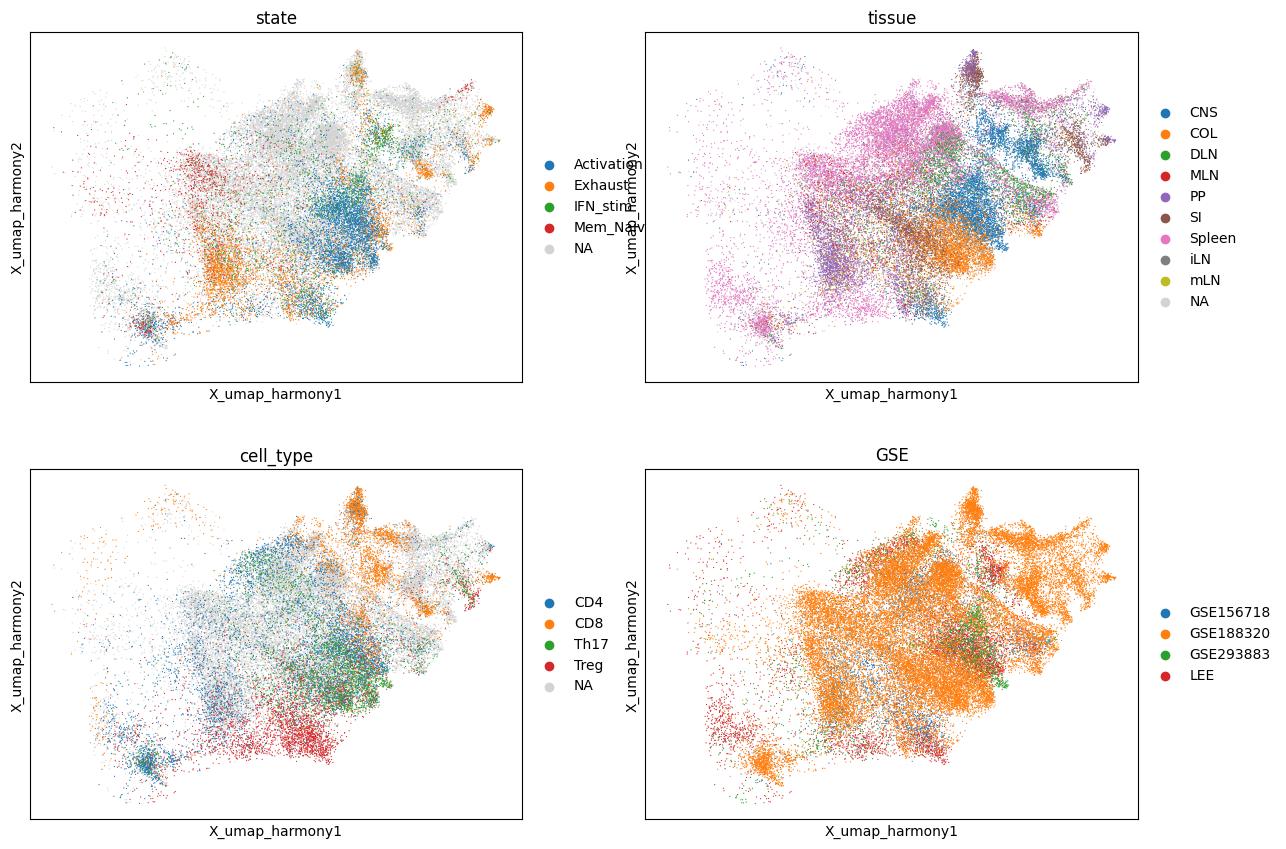

In [37]:
sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [38]:
top_n = 20
sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['CNS'], reference='rest',
                        n_genes = top_n, method='t-test')
rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)


In [39]:
rank_df.head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,B2m,133.718109,1.731350,0.0,0.0
1,Rack1,127.595413,4.075029,0.0,0.0
2,Rpl23a,117.403763,2.751351,0.0,0.0
3,Sh3bgrl3,116.417641,1.790104,0.0,0.0
4,Rps15,110.940262,1.805845,0.0,0.0


# Prepare feature array

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

In [41]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

view_tcr = np.concatenate(arrs_tcr, axis=1)
view_tcr = np.concatenate([view_tcr, mdata.obs['VDJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1),
                           mdata.obs['VJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1)],  axis=1)

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)

# biased logistic regression

In [42]:
# Logistic Regression: predict CNS vs rest using TCR features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Create binary label: CNS vs rest
y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(view_tcr, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Apply RandomOverSampler to balance classes
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
X_test, y_test = ros.fit_resample(X_test, y_test)
print(f"\nAfter oversampling:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\n{'='*60}")
print("Performance on Test Set:")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-CNS', 'CNS']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training set: 32261 samples
Test set: 8066 samples

After oversampling:
Training set: 53642 samples
Test set: 13412 samples

Performance on Test Set:
Accuracy: 0.7466
ROC AUC: 0.8173

Classification Report:
              precision    recall  f1-score   support

     Non-CNS       0.75      0.74      0.74      6706
         CNS       0.74      0.75      0.75      6706

    accuracy                           0.75     13412
   macro avg       0.75      0.75      0.75     13412
weighted avg       0.75      0.75      0.75     13412


Confusion Matrix:
[[4960 1746]
 [1652 5054]]


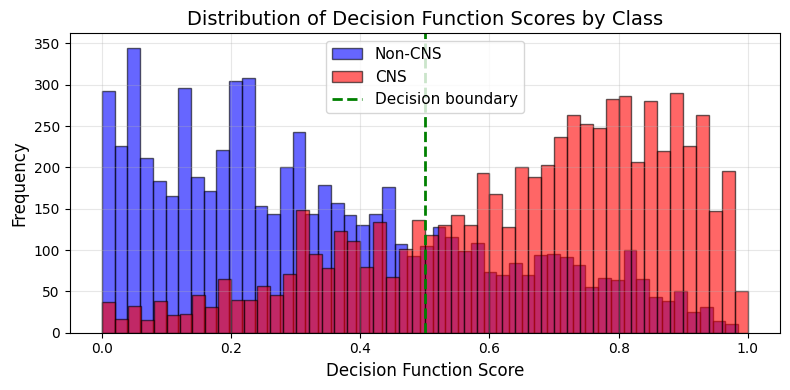

Non-CNS scores - Mean: 0.3388, Std: 0.2470
CNS scores - Mean: 0.6544, Std: 0.2302
KS statistic: 0.5005964807634954 p-value: 0.0


In [43]:
# Plot distribution of decision function for both classes
# score_p = lr_model.decision_function(X_test)
# decision_scores = (score_p - np.mean(score_p)) / np.std(score_p)

decision_scores = y_pred_proba

# Separate scores by class
scores_non_cns = decision_scores[y_test == 0]
scores_cns = decision_scores[y_test == 1]

# Create the plot
plt.figure(figsize=(8,4))
plt.hist(scores_non_cns, bins=50, alpha=0.6, label='Non-CNS', color='blue', edgecolor='black')
plt.hist(scores_cns, bins=50, alpha=0.6, label='CNS', color='red', edgecolor='black')
plt.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Decision boundary')
plt.xlabel('Decision Function Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Decision Function Scores by Class', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Non-CNS scores - Mean: {scores_non_cns.mean():.4f}, Std: {scores_non_cns.std():.4f}")
print(f"CNS scores - Mean: {scores_cns.mean():.4f}, Std: {scores_cns.std():.4f}")
from scipy.stats import ks_2samp
stat, p = ks_2samp(scores_non_cns, scores_cns)
print("KS statistic:", stat, "p-value:", p)

# Unbiased CCA

In [57]:
# Perform Canonical Correlation Analysis
# view_gene = mdata['gex'].obsm["X_pca_harmony"]
view_gene = mdata['gex'].obsm["X_pca"]
view_gene = scaler.fit_transform(view_gene)

cca = CCA(n_components=4)
view_gene_c, view_tcr_c = cca.fit_transform(view_gene, view_tcr)
print(view_gene_c.shape)
print(view_tcr_c.shape)

(40327, 4)
(40327, 4)


In [58]:
# weights
x_loadings_df = pd.DataFrame(cca.x_loadings_)
print(x_loadings_df.shape)

# There is a corresponding matrix for Y
y_loadings_df = pd.DataFrame(cca.y_loadings_)
print(y_loadings_df.shape)

(50, 4)
(550, 4)


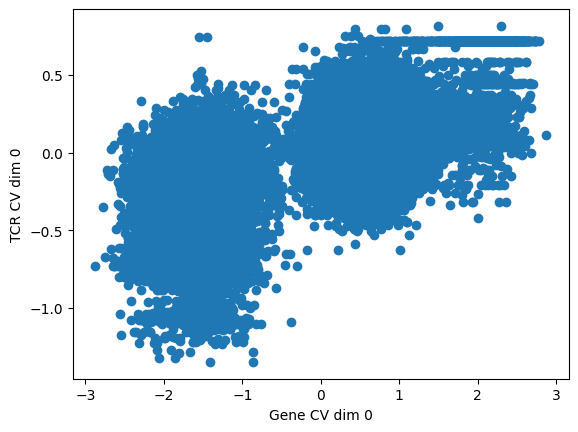

In [59]:
dim = 0
plt.scatter(view_gene_c[:, dim], view_tcr_c[:, dim])
plt.xlabel(f'Gene CV dim {dim}')
plt.ylabel(f'TCR CV dim {dim}')
plt.show()

In [60]:
# calculate the correlations

correlations = []
cv_list = []
for i in range(cca.x_loadings_.shape[1]):
  # Calculate the correlation coefficient between the i-th columns of X_c and Y_c
  # np.corrcoef returns a 2x2 matrix, the value we want is at position (0, 1)
  corr = np.corrcoef(view_gene_c[:, i], view_tcr_c[:, i])[0, 1]
  correlations.append(corr)

  mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
  # mdata['tcr'].obs['CV_score_'+str(i)] = view_tcr_c[:,i]
  cv_list.append('CV_score_'+str(i))

# Print the results
print("Canonical Correlations:")
for i, corr in enumerate(correlations):
  print(f"  Correlation for Component {i+1}: {corr:.4f}")

Canonical Correlations:
  Correlation for Component 1: 0.6654
  Correlation for Component 2: 0.6126
  Correlation for Component 3: 0.5631
  Correlation for Component 4: 0.4610


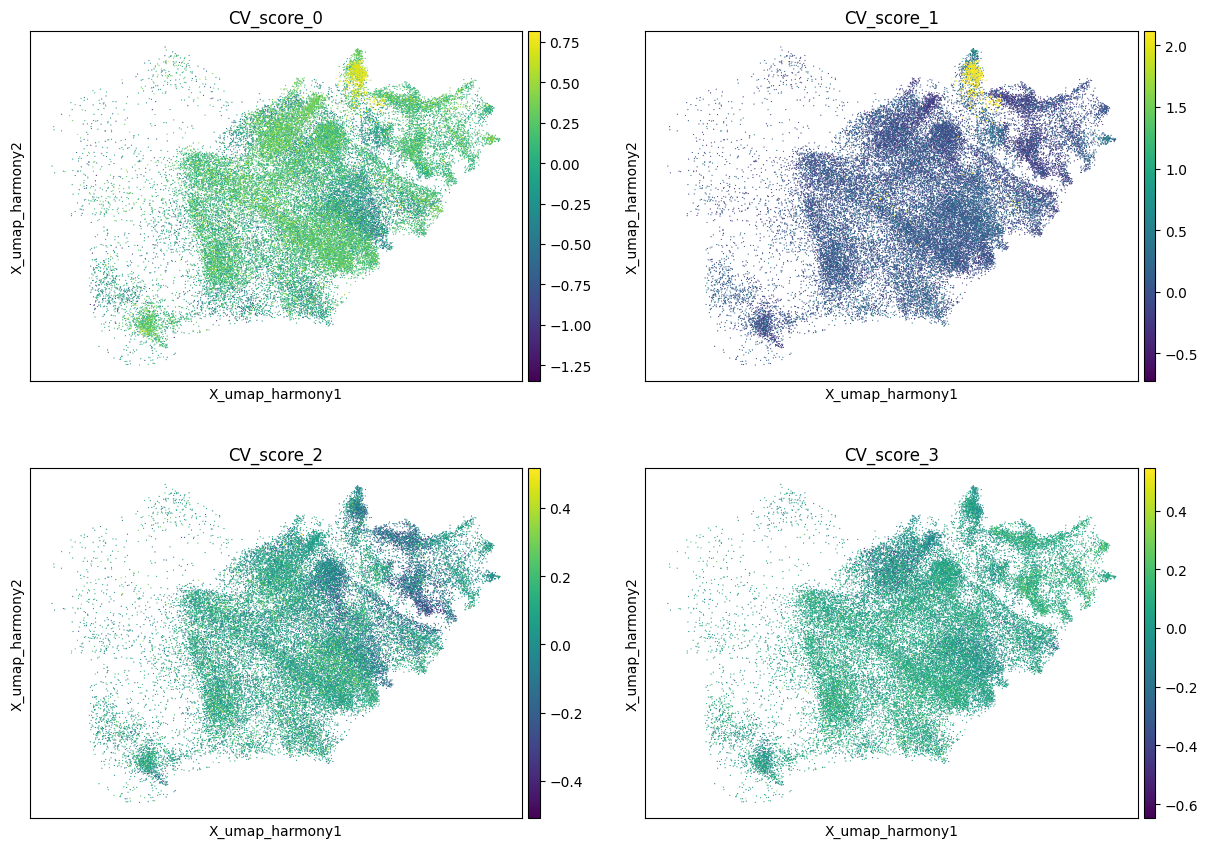

In [61]:
sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
            color= cv_list, ncols=2,)

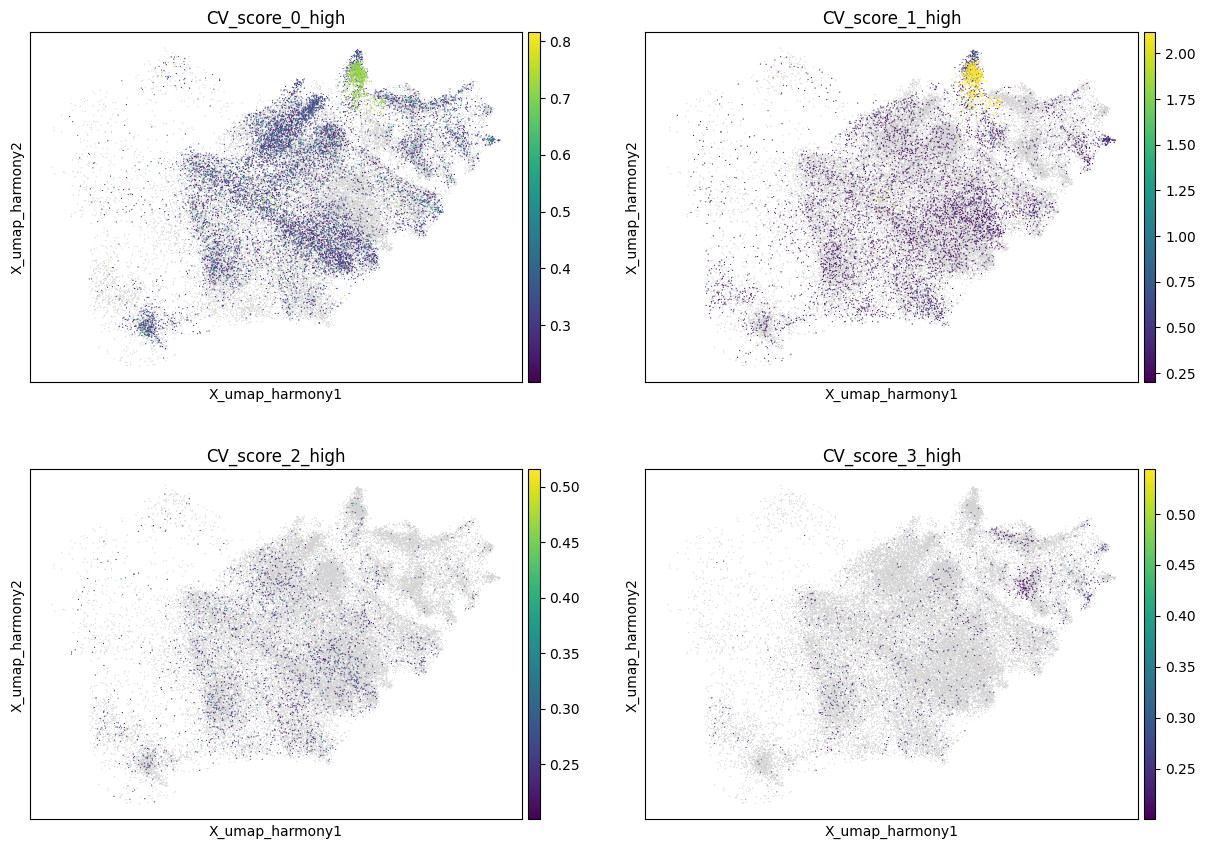

In [62]:
highlight_list = []
cutoff = 0.2
for i in range(0, 4):
    cv_name = f'CV_score_{i}'
    tmp_col = cv_name + "_high"
    highlight_list.append(tmp_col)
    
    vals = mdata['gex'].obs[cv_name].copy()
    # mdata['gex'].obs[tmp_col] = np.where(abs(vals) > cutoff, vals, np.nan)
    mdata['gex'].obs[tmp_col] = np.where(vals > cutoff, vals, np.nan)

sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
            color= highlight_list, ncols=2,)

In [63]:
## correlation 

abs_target = ['tissue', 'cell_type', 'state']
cv_thres_p = cutoff
cv_thres_n = -cutoff

# Loop through CV_score_1 to CV_score_4
all_results = []

for i in range(0, 4):
    cv_name = f'CV_score_{i}'
    
    # Get positive and negative subsets
    mdata_sub_pos = mdata[(mdata['gex'].obs[cv_name] > cv_thres_p)]
    mdata_sub_neg = mdata[(mdata['gex'].obs[cv_name] < cv_thres_n)]
    
    # Filter for Spleen or CNS tissue only
    mdata_sub_pos_filtered = mdata_sub_pos[mdata_sub_pos['gex'].obs['tissue'].isin(['Spleen', 'CNS'])]
    mdata_sub_neg_filtered = mdata_sub_neg[mdata_sub_neg['gex'].obs['tissue'].isin(['Spleen', 'CNS'])]
    
    # Calculate percentages for positive subset
    percentage_dict = {'CV_component': cv_name}
    
    for col in abs_target:
        counts = mdata_sub_pos_filtered['gex'].obs[col].value_counts()
        percentages = (counts / len(mdata_sub_pos_filtered) * 100).round(2)
        for category, pct in percentages.items():
            col_name = f'pos_{category}'
            percentage_dict[col_name] = pct
    
    # Calculate percentages for negative subset
    for col in abs_target:
        counts = mdata_sub_neg_filtered['gex'].obs[col].value_counts()
        percentages = (counts / len(mdata_sub_neg_filtered) * 100).round(2)
        for category, pct in percentages.items():
            col_name = f'neg_{category}'
            percentage_dict[col_name] = pct
    
    all_results.append(percentage_dict)

df_CV = pd.DataFrame(all_results)
df_CV
    
# labels = mdata.obs["state"]
# label_bin = (mdata.obs["state"] == 'CNS').astype(int)

,CV_component,pos_Spleen,pos_CNS,pos_CD4,pos_CD8,pos_Th17,pos_Treg,pos_Mem_Naive,pos_Activation,pos_IFN_stim,...,neg_CNS,neg_Spleen,neg_CD4,neg_CD8,neg_Treg,neg_Th17,neg_Activation,neg_Exhaust,neg_IFN_stim,neg_Mem_Naive
0,CV_score_0,89.94,10.06,9.46,5.53,3.51,2.48,3.67,3.14,3.04,...,56.65,43.35,25.72,16.48,12.68,8.34,28.80,9.35,8.19,1.56
1,CV_score_1,50.79,49.21,22.08,15.14,6.33,15.59,2.51,25.84,7.75,...,23.53,76.47,12.21,9.18,3.85,3.73,7.88,4.33,3.94,2.79
2,CV_score_2,69.68,30.32,13.47,12.53,4.53,16.74,4.32,16.53,7.79,...,54.44,45.56,20.82,15.00,2.46,6.20,16.40,14.79,3.87,0.51
3,CV_score_3,59.69,40.31,11.98,13.73,2.61,13.29,3.49,13.51,4.36,...,32.19,67.81,21.57,5.60,3.85,7.86,14.46,5.43,4.77,1.67


# correlations

In [64]:
# ANOVA tests: comparing all groups within each abs_target
from scipy.stats import f_oneway

anova_results = []

for i in range(0,4):
    cv_name = f'CV_score_{i}'
    
    for col in abs_target:
        # Get unique categories
        categories = mdata['gex'].obs[col].dropna().unique()
        
        # Collect all groups for this variable
        groups = []
        for cat in categories:
            group_data = mdata['gex'].obs[mdata['gex'].obs[col] == cat][cv_name].dropna().values
            if len(group_data) > 0:
                groups.append(group_data)
        
        # Perform ANOVA comparing all groups
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            
            anova_results.append({
                'CV_component': cv_name,
                'variable': col,
                'n_groups': len(groups),
                'F_statistic': round(f_stat, 4),
                'p_value': f'{p_value:.4e}',
                'significant': 'Yes' if p_value < 0.05 else 'No'
            })

df_anova = pd.DataFrame(anova_results)
# df_anova


In [65]:
# Calculate Pearson correlation between marker genes and CV scores
from scipy.stats import pearsonr
import seaborn as sns
    
def pearson_corr(adata, var1, markers, var_type='gene'):
    corr_results = []
    
    for cv_name in var1:
        cv_scores = adata.obs[cv_name].values

        for gene in markers:
            if gene in adata.var_names or gene in adata.obs:
                if var_type =='gene':
                    # Get gene expression values
                    gene_expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()
                
                if var_type =='obs':
                    # Get gene set scores
                    gene_expr = gene_expr = adata.obs[gene].to_numpy().flatten() 

                # Calculate Pearson correlation
                corr, p_value = pearsonr(gene_expr, cv_scores)

                corr_results.append({
                    'CV_component': cv_name,
                    'gene': gene,
                    'pearson_r': round(corr, 4),
                    'p_value': f'{p_value:.4e}',
                    'significant': 'Yes' if p_value < 0.05 else 'No'
                })
            else:
                print(f"Warning: Input '{gene}' not found in dataset")

    df_gene_corr = pd.DataFrame(corr_results)
    corr_matrix = df_gene_corr.pivot(index='CV_component', columns='gene', values='pearson_r')
    return corr_matrix
    
    

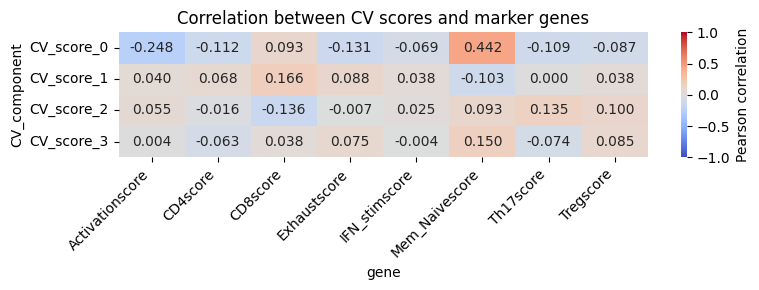

In [66]:
# Create the heatmap
cv_obs_name = [f'CV_score_{i}' for i in range(4)]
scores = ['CD4score', 'CD8score', 'Tregscore', 'Th17score',
          'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore',]

corr_matrix_obs = pearson_corr(mdata['gex'], cv_obs_name, scores, var_type='obs')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_obs, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and marker genes')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

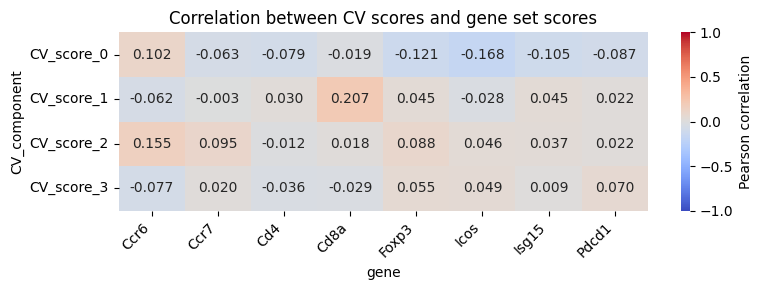

In [67]:
marker_genes = ['Cd4','Cd8a', 'Foxp3', 'Ccr6', 'Il17', 'Isg15','Icos','Pdcd1','Ccr7']
corr_matrix_genes = pearson_corr(mdata['gex'], cv_obs_name, marker_genes, var_type='gene')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and gene set scores')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

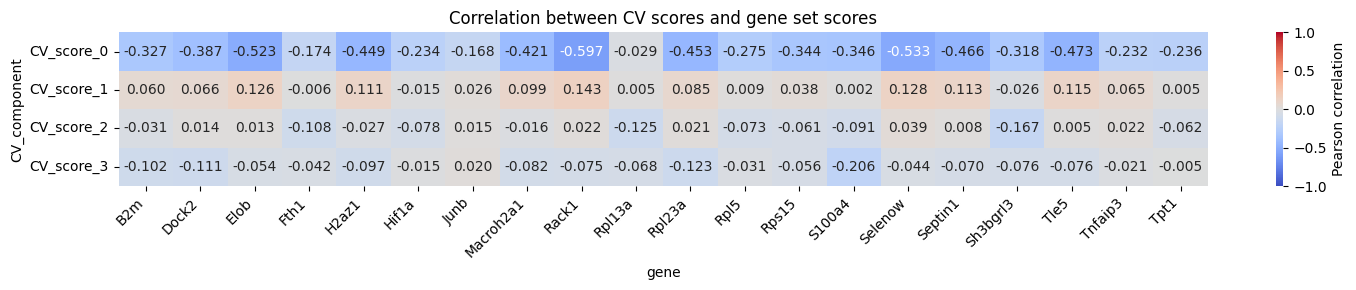

In [68]:
corr_matrix_genes = pearson_corr(mdata['gex'], cv_obs_name, rank_df['names'], var_type='gene')

plt.figure(figsize=(15, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and gene set scores')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

# Save

In [69]:
# import anndata as ad
# ad.settings.allow_write_nullable_strings = True
# mdata.write('merged_EAE_TCRemb.h5mu')